Using device: cuda
Trying to load model from: /home/student/sky-scan/notebooks/models/conservative_roof_texture_model.pth
✅ Model loaded successfully from: /home/student/sky-scan/notebooks/models/conservative_roof_texture_model.pth
Model type: ConservativeRoofClassifier
✅ Model loaded successfully!
🔍 Searching for available images...

📁 Found 12 image(s):
  0: /home/student/sky-scan/data/patch/12_2304_2304.png (0.1MB)
  1: /home/student/sky-scan/data/patch/8_4736_1280.png (0.1MB)
  2: /home/student/sky-scan/data/patch/4_2048_384.png (0.1MB)
  3: /home/student/sky-scan/data/patch/1_1664_3456.png (0.1MB)
  4: /home/student/sky-scan/data/patch/11_3968_3584.png (0.0MB)
  5: /home/student/sky-scan/data/patch/8_2048_3200.png (0.1MB)
  6: /home/student/sky-scan/data/patch/8_2304_640.png (0.1MB)
  7: /home/student/sky-scan/data/patch/2_2944_3584.png (0.1MB)
  8: /home/student/sky-scan/data/patch/4_2944_1152.png (0.1MB)
  9: /home/student/sky-scan/data/patch/8_1664_2432.png (0.1MB)
  10: /home/

libpng warning: iCCP: known incorrect sRGB profile



📊 Prediction Stats:
 smooth: 0 tiles (0.0%), avg conf=0.000
 average: 4 tiles (100.0%), avg conf=0.716
 rough: 0 tiles (0.0%), avg conf=0.000


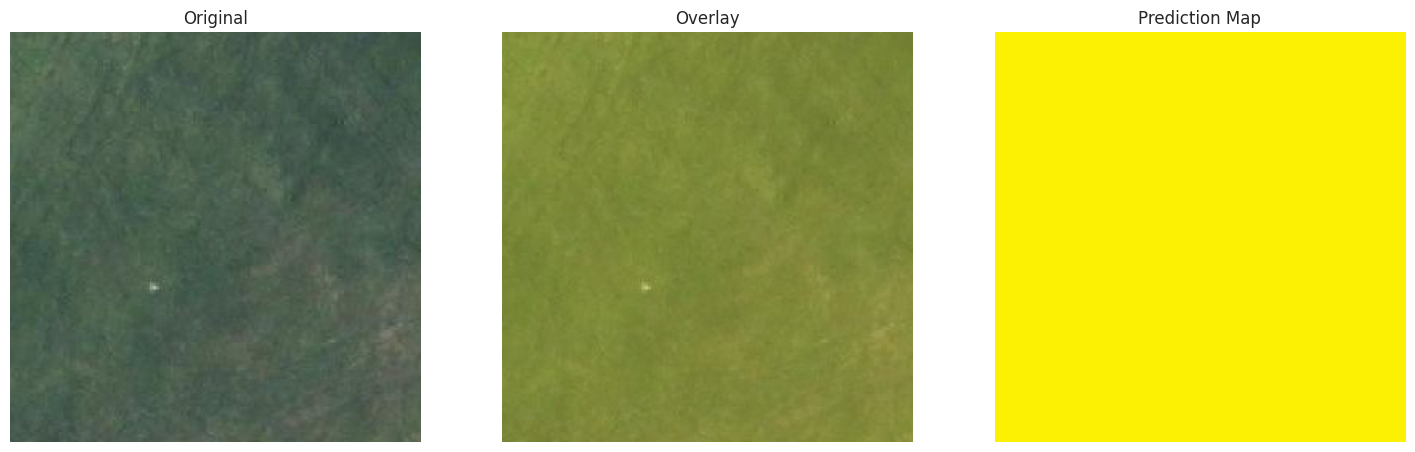

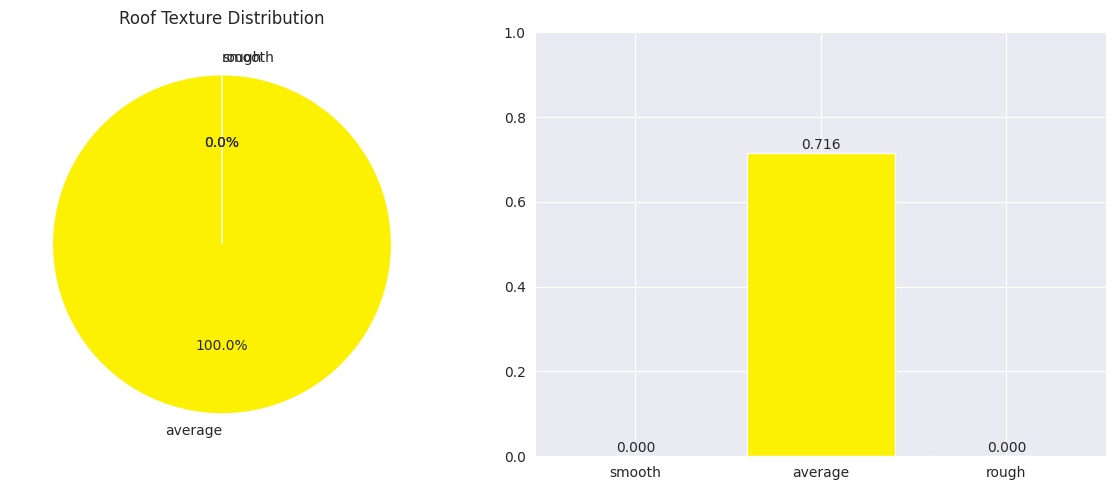

✅ Saved results to inference_results/

🎉 Inference completed successfully!
📊 Results saved to: inference_results/

ROOF TEXTURE CLASSIFICATION - INFERENCE
📝 Current Status:
  Model: ✅ Loaded
  Device: cuda
  Model file: /home/student/sky-scan/notebooks/models/conservative_roof_texture_model.pth


In [2]:
import os
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import matplotlib.pyplot as plt
from PIL import Image
import warnings

warnings.filterwarnings('ignore')
os.environ['OPENCV_LOG_LEVEL'] = 'SILENT'

# -------------------------------
# Model Architectures
# -------------------------------
class RoofTextureClassifier(nn.Module):
    """Roof texture classification model"""

    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class ConservativeRoofClassifier(nn.Module):
    """Conservative model with batch normalization"""

    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(num_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

class ImprovedRoofTextureClassifier(nn.Module):
    """Improved CNN model with better regularization"""
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.7),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

# -------------------------------
# Config & Utilities
# -------------------------------
class InferenceConfig:
    # Updated paths based on the correct absolute path provided by user
    BASE_PATH = "/home/student/sky-scan/notebooks"  # Correct absolute path
    MODEL_PATH = "/home/student/sky-scan/notebooks/models/conservative_roof_texture_model.pth"
    BACKUP_MODEL_PATHS = [
        "/home/student/sky-scan/notebooks/models/roof_texture_model.pth",
        "/home/student/sky-scan/notebooks/models/improved_roof_texture_model.pth",
        "/home/student/sky-scan/notebooks/models/conservative_roof_texture_model.pth",
        "/home/student/sky-scan/notebooks/best_roof_classifier.pth",
        "/home/student/sky-scan/models/roof_texture_model.pth",
        "/home/student/sky-scan/models/conservative_roof_texture_model.pth",
        "/home/student/sky-scan/models/improved_roof_texture_model.pth",
        "models/roof_texture_model.pth",  # Relative paths as fallback
        "models/conservative_roof_texture_model.pth",
        "best_roof_classifier.pth"
    ]
    # Available images in the correct directory
    SAMPLE_IMAGES = [
        "/home/student/sky-scan/notebooks/output.png",
        "/home/student/sky-scan/notebooks/learning graph 17 augest.png",
        "/home/student/sky-scan/notebooks/with_3_classes_imrpove_cloudav1.png",
        "/home/student/sky-scan/data/patch"  # Training data location
    ]
    IMAGE_SIZE = 224
    TILE_SIZE = 256
    OVERLAP = 32
    BATCH_SIZE = 16
    CLASS_LABELS = ['smooth', 'average', 'rough']
    CLASS_COLORS = {
        'smooth': (83, 217, 56),
        'average': (252, 240, 3),
        'rough': (255, 0, 0)
    }

config = InferenceConfig()

def get_device():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    return device

device = get_device()

# -------------------------------
# Load Model
# -------------------------------
def load_model(model_path=None, num_classes=3, model_type='auto'):
    """Load model with automatic fallback to available model files"""

    # Try different model paths
    paths_to_try = []
    if model_path:
        paths_to_try.append(model_path)

    paths_to_try.extend(config.BACKUP_MODEL_PATHS)

    model = None
    loaded_path = None

    for path in paths_to_try:
        if os.path.exists(path):
            try:
                print(f"Trying to load model from: {path}")

                # Load checkpoint
                checkpoint = torch.load(path, map_location=device)

                # Determine model type from checkpoint or filename
                if isinstance(checkpoint, dict) and 'model_class' in checkpoint:
                    model_class = checkpoint['model_class']
                elif 'conservative' in path.lower():
                    model_class = 'ConservativeRoofClassifier'
                elif 'improved' in path.lower():
                    model_class = 'ImprovedRoofTextureClassifier'
                else:
                    model_class = 'RoofTextureClassifier'

                # Initialize appropriate model
                if model_class == 'ConservativeRoofClassifier':
                    model = ConservativeRoofClassifier(num_classes)
                elif model_class == 'ImprovedRoofTextureClassifier':
                    model = ImprovedRoofTextureClassifier(num_classes)
                else:
                    model = RoofTextureClassifier(num_classes)

                # Load state dict
                if isinstance(checkpoint, dict):
                    if 'model_state_dict' in checkpoint:
                        model.load_state_dict(checkpoint['model_state_dict'])
                    elif 'state_dict' in checkpoint:
                        model.load_state_dict(checkpoint['state_dict'])
                    else:
                        model.load_state_dict(checkpoint)
                else:
                    model.load_state_dict(checkpoint)

                loaded_path = path
                print(f"✅ Model loaded successfully from: {path}")
                print(f"Model type: {model_class}")
                break

            except Exception as e:
                print(f"❌ Failed to load {path}: {e}")
                continue

    if model is None:
        print("❌ No model file found. Available paths tried:")
        for path in paths_to_try:
            exists = "✓" if os.path.exists(path) else "✗"
            print(f"  {exists} {path}")
        raise FileNotFoundError("No valid model file found")

    model.to(device)
    model.eval()
    return model, loaded_path

try:
    model, model_path = load_model(config.MODEL_PATH)
    print("✅ Model loaded successfully!")
except FileNotFoundError as e:
    print(f"❌ {e}")
    model = None
    model_path = None

# -------------------------------
# Preprocessing
# -------------------------------
def get_inference_transform(image_size=224):
    return transforms.Compose([
        transforms.ToPILImage(),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

transform = get_inference_transform(config.IMAGE_SIZE)

# -------------------------------
# Tile Extraction
# -------------------------------
def extract_tiles(image, tile_size=256, overlap=32):
    h, w = image.shape[:2]
    tiles, positions = [], []
    stride = tile_size - overlap

    for y in range(0, h - tile_size + 1, stride):
        for x in range(0, w - tile_size + 1, stride):
            tile = image[y:y+tile_size, x:x+tile_size]
            tiles.append(tile)
            positions.append((x, y))

    if w % stride != 0:
        x = w - tile_size
        for y in range(0, h - tile_size + 1, stride):
            tile = image[y:y+tile_size, x:x+tile_size]
            tiles.append(tile)
            positions.append((x, y))

    if h % stride != 0:
        y = h - tile_size
        for x in range(0, w - tile_size + 1, stride):
            tile = image[y:y+tile_size, x:x+tile_size]
            tiles.append(tile)
            positions.append((x, y))

    if w % stride != 0 and h % stride != 0:
        x, y = w - tile_size, h - tile_size
        tile = image[y:y+tile_size, x:x+tile_size]
        tiles.append(tile)
        positions.append((x, y))

    return tiles, positions

def preprocess_tiles(tiles, transform):
    processed = []
    for tile in tiles:
        if len(tile.shape) == 3 and tile.shape[2] == 3:
            tile_rgb = cv2.cvtColor(tile, cv2.COLOR_BGR2RGB)
        else:
            tile_rgb = tile
        processed.append(transform(tile_rgb))
    return torch.stack(processed)

# -------------------------------
# Inference
# -------------------------------
def predict_tiles(model, tiles_tensor, batch_size=16):
    model.eval()
    preds, confs = [], []
    with torch.no_grad():
        for i in range(0, len(tiles_tensor), batch_size):
            batch = tiles_tensor[i:i+batch_size].to(device)
            outputs = model(batch)
            probabilities = F.softmax(outputs, dim=1)
            conf, pred = torch.max(probabilities, 1)
            preds.extend(pred.cpu().numpy())
            confs.extend(conf.cpu().numpy())
    return preds, confs

def get_class_name(idx):
    return config.CLASS_LABELS[idx] if idx < len(config.CLASS_LABELS) else 'unknown'

# -------------------------------
# Visualization
# -------------------------------
def create_colored_tile(tile, class_name, confidence, alpha=0.3):
    color = config.CLASS_COLORS.get(class_name, (128,128,128))
    overlay = np.full_like(tile, color, dtype=np.uint8)
    alpha_conf = alpha * confidence
    return cv2.addWeighted(tile, 1-alpha_conf, overlay, alpha_conf, 0)

def merge_tiles_with_predictions(original, tiles, positions, preds, confs, tile_size=256, overlap=32, alpha=0.3):
    h, w = original.shape[:2]
    result = original.copy()
    weight_map = np.zeros((h,w), dtype=np.float32)
    accumulator = np.zeros((h,w,3), dtype=np.float32)

    for tile, (x,y), p, conf in zip(tiles, positions, preds, confs):
        cls = get_class_name(p)
        colored = create_colored_tile(tile, cls, conf, alpha)
        end_x, end_y = min(x+tile_size,w), min(y+tile_size,h)
        th, tw = end_y-y, end_x-x
        weight_map[y:end_y,x:end_x]+=conf
        accumulator[y:end_y,x:end_x]+=colored[:th,:tw]*conf

    mask = weight_map>0
    result[mask] = (accumulator[mask]/weight_map[mask,None]).astype(np.uint8)
    return result

def create_prediction_map(shape, positions, preds, confs, tile_size=256):
    h, w = shape[:2]
    prediction_map = np.zeros((h,w,3), dtype=np.uint8)
    for (x,y), p, conf in zip(positions, preds, confs):
        cls = get_class_name(p)
        color = config.CLASS_COLORS.get(cls, (128,128,128))
        end_x, end_y = min(x+tile_size,w), min(y+tile_size,h)
        prediction_map[y:end_y,x:end_x]=color
    return prediction_map

# -------------------------------
# Stats
# -------------------------------
def analyze_predictions(preds, confs):
    stats={}
    for i,cls in enumerate(config.CLASS_LABELS):
        mask=np.array(preds)==i
        count=np.sum(mask)
        avg=np.mean(np.array(confs)[mask]) if count>0 else 0
        stats[cls]={'count':count,'percentage':count/len(preds)*100,'avg_confidence':avg}
    return stats

def plot_statistics(stats):
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,5))
    classes=list(stats.keys())
    counts=[stats[c]['count'] for c in classes]
    colors=[tuple(c/255.0 for c in config.CLASS_COLORS[c]) for c in classes]
    ax1.pie(counts,labels=classes,colors=colors,autopct='%1.1f%%',startangle=90)
    ax1.set_title("Roof Texture Distribution")
    confs=[stats[c]['avg_confidence'] for c in classes]
    bars=ax2.bar(classes,confs,color=colors)
    ax2.set_ylim(0,1)
    for bar,conf in zip(bars,confs):
        ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f"{conf:.3f}",ha="center")
    plt.tight_layout()
    plt.show()

# -------------------------------
# Main Function
# -------------------------------
def process_image(image_path, model, save_results=True, output_dir="inference_results"):
    if model is None:
        print("❌ Model not loaded")
        return None
    if not os.path.exists(image_path):
        print("❌ Image not found:",image_path)
        return None

    image=cv2.imread(image_path)
    if image is None:
        print("❌ Failed to load:",image_path)
        return None
    image_rgb=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    tiles,positions=extract_tiles(image_rgb,config.TILE_SIZE,config.OVERLAP)
    tiles_tensor=preprocess_tiles(tiles,transform)
    preds,confs=predict_tiles(model,tiles_tensor,config.BATCH_SIZE)

    stats=analyze_predictions(preds,confs)
    print("\n📊 Prediction Stats:")
    for c,s in stats.items():
        print(f" {c}: {s['count']} tiles ({s['percentage']:.1f}%), avg conf={s['avg_confidence']:.3f}")

    colored=merge_tiles_with_predictions(image_rgb,tiles,positions,preds,confs,config.TILE_SIZE,config.OVERLAP,alpha=0.4)
    prediction_map=create_prediction_map(image_rgb.shape,positions,preds,confs,config.TILE_SIZE)

    fig,axes=plt.subplots(1,3,figsize=(18,6))
    axes[0].imshow(image_rgb);axes[0].set_title("Original");axes[0].axis("off")
    axes[1].imshow(colored);axes[1].set_title("Overlay");axes[1].axis("off")
    axes[2].imshow(prediction_map);axes[2].set_title("Prediction Map");axes[2].axis("off")
    plt.show()

    plot_statistics(stats)

    if save_results:
        os.makedirs(output_dir,exist_ok=True)
        base=os.path.splitext(os.path.basename(image_path))[0]
        cv2.imwrite(os.path.join(output_dir,f"{base}_colored.jpg"),cv2.cvtColor(colored,cv2.COLOR_RGB2BGR))
        cv2.imwrite(os.path.join(output_dir,f"{base}_map.jpg"),cv2.cvtColor(prediction_map,cv2.COLOR_RGB2BGR))
        print(f"✅ Saved results to {output_dir}/")

    return {'original':image_rgb,'colored':colored,'map':prediction_map,'stats':stats,'preds':preds,'confs':confs}

# -------------------------------
# Example usage and Image Path Detection
# -------------------------------
def find_sample_images():
    """Find available sample images in the workspace"""
    possible_paths = [
        # Correct absolute paths based on user's environment
        "/home/student/sky-scan/notebooks/output.png",
        "/home/student/sky-scan/notebooks/learning graph 17 augest.png",
        "/home/student/sky-scan/notebooks/with_3_classes_imrpove_cloudav1.png",

        # Training data directory
        "/home/student/sky-scan/data/patch",

        # Current directory and common locations
        "/home/student/sky-scan/notebooks",
        "/home/student/sky-scan/data",
        "/home/student/sky-scan/images",
        "/home/student/sky-scan/test_images",

        # Relative paths as fallback
        ".",
        "./output.png",
        "./notebooks",
        "./data"
    ]

    found_images = []
    image_extensions = ['.jpg', '.jpeg', '.png', '.tiff', '.bmp', '.JPG', '.JPEG', '.PNG']

    for base_path in possible_paths:
        if os.path.exists(base_path):
            if os.path.isfile(base_path) and any(base_path.endswith(ext) for ext in image_extensions):
                found_images.append(base_path)
            elif os.path.isdir(base_path):
                try:
                    for file in os.listdir(base_path):
                        if any(file.endswith(ext) for ext in image_extensions):
                            full_path = os.path.join(base_path, file)
                            found_images.append(full_path)
                            if len(found_images) >= 10:  # Limit to first 10 found
                                break
                except PermissionError:
                    continue

    return found_images

def interactive_image_selection():
    """Interactive image selection for inference"""
    print("🔍 Searching for available images...")
    found_images = find_sample_images()

    if found_images:
        print(f"\n📁 Found {len(found_images)} image(s):")
        for i, img_path in enumerate(found_images):
            size_info = ""
            try:
                if os.path.exists(img_path):
                    # Get file size
                    size_mb = os.path.getsize(img_path) / (1024 * 1024)
                    size_info = f" ({size_mb:.1f}MB)"
            except:
                pass
            print(f"  {i}: {img_path}{size_info}")

        print(f"\nTo use an image, update IMAGE_PATH in the code:")
        print(f"IMAGE_PATH = \"{found_images[0]}\"  # Example")
        return found_images[0]  # Return first found image as default
    else:
        print("❌ No images found in common locations.")
        print("\n💡 To add images:")
        print("  1. Place image files in: /home/student/sky-scan/notebooks/")
        print("  2. Or update the data path in training config")
        print("  3. Or manually set IMAGE_PATH to your image location")
        return None

# Run interactive image search
default_image = interactive_image_selection()

if __name__ == "__main__":
    # Set your image path here
    IMAGE_PATH = default_image or "/home/student/sky-scan/notebooks/output.png"

    print(f"\n🖼️  Processing image: {IMAGE_PATH}")

    if model is None:
        print("\n❌ Model not loaded. Please ensure you have a trained model file.")
        print("Expected model files:")
        for path in config.BACKUP_MODEL_PATHS:
            exists = "✓" if os.path.exists(path) else "✗"
            print(f"  {exists} {path}")
        print("\n💡 To train a model, run the training script from with_3_classes_improve file")

    elif os.path.exists(IMAGE_PATH):
        print("✅ Image found. Starting inference...")
        result = process_image(IMAGE_PATH, model)
        if result:
            print(f"\n🎉 Inference completed successfully!")
            print(f"📊 Results saved to: inference_results/")
    else:
        print(f"❌ Image not found: {IMAGE_PATH}")
        print("\n💡 Please:")
        print("  1. Update IMAGE_PATH variable above")
        print("  2. Or place an image file in the notebooks folder")
        print("  3. Or use the interactive_image_selection() function")

# Alternative: Manual image path setup
def setup_manual_paths():
    """Manual setup for custom paths"""
    print("\n🔧 MANUAL SETUP:")
    print("1. Set your model path:")
    print("   MODEL_PATH = '/path/to/your/model.pth'")
    print("\n2. Set your image path:")
    print("   IMAGE_PATH = '/path/to/your/image.jpg'")
    print("\n3. Run: process_image(IMAGE_PATH, model)")

print("\n" + "="*50)
print("ROOF TEXTURE CLASSIFICATION - INFERENCE")
print("="*50)
print("📝 Current Status:")
print(f"  Model: {'✅ Loaded' if model else '❌ Not loaded'}")
print(f"  Device: {device}")
if model:
    print(f"  Model file: {model_path}")
print("="*50)


In [3]:
!ls
!pwd

best_roof_classifier.pth  jupyter_training_runner.py  models
checkpoints		  model_info.pkl	      training_history.png
inference_results	  model_traning_v2.py
/home/student/sky-scan/notebooks
